# Final Project
**Team Members:** Dipesh Ghimire, Charles Benello, Wan Hwang

**Course:** FINM 33160 1 (Winter 2026) Machine Learning for Finance

In [ ]:
import warnings

import re
import time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import optuna
from optuna.samplers import TPESampler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor

warnings.filterwarnings("ignore")

## Loading the Cleaned CRSP Monthly Parquet File
We load the cleaned data from `data/crsp_monthly.parquet`. This Parquet file is produced by running the data cleaning pipeline in `csv_to_parquet.py`, which standardizes column names, sorts by identifier and date, converts data types, removes zero or negative prices, and ensures return values are valid for analysis.

In [2]:
# Load the CRSP monthly parquet file
crsp_monthly = pd.read_parquet("data/crsp_monthly.parquet")
crsp_monthly.sort_values(by= ['date', 'permno'], inplace=True)

# Display the lasy 10 rows of the dataset
display(crsp_monthly.tail(10).style.set_caption("CRSP Monthly Data - Last 10 Rows"))

,permno,date,shrcd,siccd,ticker,comnam,prc,ret,shrout
4959652,93397,2024-12-31 00:00:00,11.000000,9999.0,LMNR,LIMONEIRA CO,24.460000,-0.117446,18033.000000
4961326,93419,2024-12-31 00:00:00,18.000000,6798.0,HPP,HUDSON PACIFIC PROPERTIES INC,3.030000,-0.212987,141232.000000
4961623,93421,2024-12-31 00:00:00,73.000000,6726.0,PICB,INVESCO E T F TRUST II,21.580000,-0.032007,5700.000000
4962092,93424,2024-12-31 00:00:00,74.000000,6221.0,CORN,TEUCRIUM COMMODITY TRUST,18.770000,0.050375,3450.000000
4962266,93425,2024-12-31 00:00:00,74.000000,6221.0,BNO,UNITED STATES BRENT OIL FUND LP,29.950000,0.032759,3800.000000
4962439,93426,2024-12-31 00:00:00,11.000000,3676.0,VPG,VISHAY PRECISION GROUP INC,23.470000,0.021768,12216.000000
4962613,93427,2024-12-31 00:00:00,12.000000,3826.0,FN,FABRINET,219.880000,-0.062665,36268.000000
4962878,93429,2024-12-31 00:00:00,11.000000,6211.0,CBOE,C B O E GLOBAL MARKETS INC,195.399990,-0.094742,104686.000000
4963204,93434,2024-12-31 00:00:00,11.000000,9999.0,SANW,S & W SEED CO,7.990000,0.133333,2284.000000
4963400,93436,2024-12-31 00:00:00,11.000000,9999.0,TSLA,TESLA INC,403.840000,0.170008,3210060.000000


In [3]:
# Subset the dataset for common stock (shrcd = 10, 11 and 12)
crsp_monthly = crsp_monthly[crsp_monthly['shrcd'].isin([10, 11, 12])]

## Feature Engineering

##### Cross-Sectional Price-Based Features Identified as Anomalies in Finance Literature

In this project, we construct a set of cross-sectional features derived from asset prices, all of which have been documented as anomalies in the academic finance literature. Each feature is motivated by an economic hypothesis about asset pricing, and we cite the relevant papers justifying its use.

### 1) **Momentum (3M, 6M, 9M, and 12-1M "Classic" Lookback)**

**Economic Hypothesis:**  
The momentum anomaly refers to the empirical tendency for stocks that have performed well in the past to continue to perform well in the near future, and vice versa for poorly performing stocks. This is commonly explained by the *underreaction hypothesis* (Jegadeesh & Titman, 1993), which posits that investors are slow to incorporate new information, causing positive (or negative) trends to persist over intermediate horizons.

**Implementation:**  
We compute cumulative returns over different lookback periods: 3 months, 6 months, 9 months, and the classic 12-month lookback skipping the most recent month. ~ *Jegadeesh & Titman (1993): "Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency (JFE)"*).

In [4]:
# 1) Price Momentum Based Features
crsp_monthly['12m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(12).mean().shift(2))
crsp_monthly['9m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(9).mean().shift(2))
crsp_monthly['6m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(6).mean().shift(2))
crsp_monthly['3m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(3).mean().shift(2))

### 2) **Mean Reversion ("Short-Term Reversal")**

**Economic Hypothesis:**  
Stocks that performed poorly in the previous month tend to outperform in the following month, and vice versa. This short-term reversal is commonly attributed to overreaction by investors and temporary liquidity shocks. (*Jegadeesh, 1990: "Evidence of Predictable Behavior of Security Returns"*).

**Implementation:**  
We create a one-month lagged return ("1M momentum") feature to quantify this mean reversion effect.

In [5]:
# 2) Mean Reversion Based Features
crsp_monthly['1m_mean_reversion'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(1))

### 3) **Price Bins (Lagged Price Discretization)**

**Economic Hypothesis:**  
Empirical studies have found that low-priced stocks, when sorted into bins by share price, tend to yield higher cross-sectional average returns than high-priced stocks. One hypothesis is that price may serve as a proxy for mispricing or neglected risk. For example, *Asness, Frazzini, Israel, & Moskowitz (2015): "Fact, Fiction, and Value Investing"* discusses discrete price effects, and *Birru & Wang (2016): "Nominal Prices Matter"* specifically notes that lower-priced stocks earn higher returns due to investor biases and constraints related to nominal pricing.

**Implementation:**  
We discretize lagged prices (e.g., price at t-1) into bins and use them as categorical features.

In [6]:
# 3) Price Bins Based Features
crsp_monthly['lag_prc'] = crsp_monthly.groupby('permno')['prc'].shift(1)
crsp_monthly.dropna(subset=['lag_prc'], inplace=True)

crsp_monthly['lag_prc_bin'] = crsp_monthly.groupby('date')['lag_prc'].transform(lambda x: pd.qcut(x, q=5, labels=False))

### 4) **Log Market Capitalization (Log MktCap = log(shrout × prc))**

**Economic Hypothesis:**  
The *size effect* refers to the observation that small-capitalization firms (i.e., those with lower market capitalization) tend to outperform large-cap firms on a risk-adjusted basis. This anomaly is well-documented in the literature, particularly in *Banz (1981): "The Relationship Between Return and Market Value of Common Stocks"* and *Fama & French (1993): "Common Risk Factors in the Returns on Stocks and Bonds"*.

**Implementation:**  
We compute the log of market capitalization for each stock as log(shares outstanding × price).

In [7]:
# 4) Log Market Capitalization Based Features
crsp_monthly['log_mktcap'] = np.log(crsp_monthly['shrout'] * crsp_monthly['prc'])
crsp_monthly['log_mktcap'] = crsp_monthly.groupby('permno')['log_mktcap'].transform(lambda x: x.shift(1))
crsp_monthly.dropna(subset=['log_mktcap'], inplace=True)

### 5) **Seasonality in the Cross Section ("Return Seasonality" / Calendar-Time Effects)**
 
**Economic Hypothesis:**  
Seasonality in the cross section refers to the well-documented finding that a stock’s return from one year ago (lag 12 months), two years ago (24 months), and even three years ago (36 months) can positively predict its return today, i.e., stocks that outperformed in a given month one, two, or three years earlier tend to outperform contemporaneously. This seasonal pattern is interpreted as evidence of periodic behavioral biases or institutional frictions that repeat on an annual cycle. Notably, Heston and Sadka (2008) provide strong empirical evidence for this phenomenon.
 
**Implementation:**  
We create features for each stock’s return lagged exactly 12, 24, and 36 months, respectively. These lagged monthly returns are commonly named “12M seasonality”, “24M seasonality”, and “36M seasonality” features, following the methodology of Heston & Sadka (2008).

In [8]:
# 5) Seasonality Based Features
crsp_monthly['12m_seasonality'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(12))
crsp_monthly['24m_seasonality'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(24))
crsp_monthly['36m_seasonality'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(36))

### 6) **Interaction Effects**
 
**Economic Hypothesis:**  
The interaction between the above features may capture additional non-linearities in returns that are missed by modeling each anomaly in isolation. For example, momentum may be stronger in small cap stocks, or the price effect may be conditional on recent returns (*Daniel & Titman, 1997: "Evidence on the Characteristics of Cross Sectional Variation in Stock Returns"*). Including interaction terms allows us to empirically test for such joint effects documented in the literature.

In [9]:
# 6) Features Capturing Interaction Effects

## Lagged Prices and Momentum
crsp_monthly['interaction_12m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['12m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_9m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['9m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_6m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['6m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_3m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['3m_momentum'].transform(lambda x: (x - x.mean()) / x.std())

## Lagged Prices and Mean Reversion
crsp_monthly['interaction_1m_mean_reversion_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['1m_mean_reversion'].transform(lambda x: (x - x.mean()) / x.std())

## Log Market Capitalization and Momentum
crsp_monthly['log_mktcap_bin'] = crsp_monthly.groupby('date')['log_mktcap'].transform(lambda x: pd.qcut(x, q=5, labels=False))
crsp_monthly['interaction_log_mktcap_bin_12m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['12m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_log_mktcap_bin_9m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['9m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_log_mktcap_bin_6m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['6m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_log_mktcap_bin_3m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['3m_momentum'].transform(lambda x: (x - x.mean()) / x.std())

## Log Market Capitalization and Mean Reversion
crsp_monthly['interaction_log_mktcap_bin_1m_mean_reversion'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['1m_mean_reversion'].transform(lambda x: (x - x.mean()) / x.std())

**References:**
- Jegadeesh, N., & Titman, S. (1993). Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency. *Journal of Finance, 48*(1), 65-91.
- Jegadeesh, N. (1990). Evidence of Predictable Behavior of Security Returns. *Journal of Finance, 45*(3), 881-898.
- Birru, J., & Wang, B. (2016). Nominal Prices Matter. *Review of Financial Studies, 29*(4), 976–1010.
- Banz, Rolf W. (1981). The Relationship Between Return and Market Value of Common Stocks. *Journal of Financial Economics, 9*(1), 3–18.
- Fama, E. F., & French, K. R. (1993). Common Risk Factors in the Returns on Stocks and Bonds. *Journal of Financial Economics, 33*(1), 3-56.
- Asness, C. S., Frazzini, A., Israel, R., & Moskowitz, T. J. (2015). Fact, Fiction, and Value Investing. *Journal of Portfolio Management, 42*(1), 34-52.
- Daniel, K. & Titman, S. (1997). Evidence on the Characteristics of Cross Sectional Variation in Stock Returns. *Journal of Finance, 52*(1), 1–33.
- Heston, S. L., & Sadka, R. (2008). Seasonality in the Cross-Section of Stock Returns. *Journal of Financial Economics, 87*(2), 418-445.

## Select Required Columns

In [10]:
# Select only the required columns
columns_to_drop = ['shrcd', 'siccd', 'ticker', 'comnam', 'prc', 'shrout', 'lag_prc', 'log_mktcap_bin']
crsp_monthly.drop(columns=columns_to_drop, inplace=True)

# Set the date column as the index
crsp_monthly.set_index('date', inplace=True)

# Drop rows with missing values
crsp_monthly.dropna(inplace=True)

## Create Target for Regression Model

The regression target is created as a cross-sectional winsorized z-score of **month \(t\)** realized returns (CRSP `ret`).

- For each month \(t\), we take the cross section of stock returns \(r_{i,t}\), winsorize extreme values (0.5th and 99.5th percentiles), and then compute a z-score by subtracting the cross-sectional mean and dividing by the cross-sectional standard deviation.
- Although the target is \(r_t\) (same-row return), our predictors are constructed using only information available by the end of **month \(t-1\)** (via lags / skip-month conventions). Therefore, the model represents a one-month-ahead forecasting setup without look-ahead bias.

This normalization makes the target more robust to outliers and comparable across time.

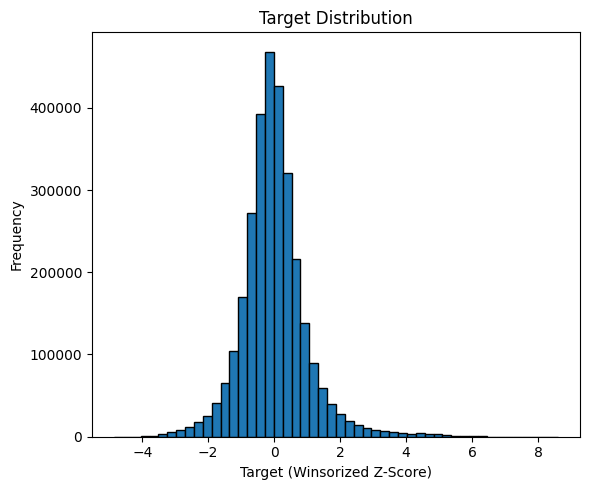

In [11]:
def cs_winsorized_z(x, lower=0.005, upper=0.995):
    lo, hi = x.quantile([lower, upper])
    x_clip = x.clip(lo, hi)
    return (x_clip - x_clip.mean()) / x_clip.std()

crsp_monthly['target'] = crsp_monthly.groupby('date')['ret'].transform(cs_winsorized_z)
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(crsp_monthly['target'], bins=50, edgecolor='black')
ax.set_title('Target Distribution')
ax.set_xlabel('Target (Winsorized Z-Score)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Prepare Train, Validation, and Test Set
### Methodology (Train / Validate / Refit / Test)
We follow a standard out-of-sample (OOS) evaluation workflow designed to prevent information leakage from the test period into model selection.

#### 1) Chronological split (to avoid look-ahead bias)
Because the data are indexed by time, we split the sample by date:

- **Training set (2000-01-01 to 2009-12-31)**: fit candidate models.
- **Validation set (2010-01-01 to 2014-12-31)**: tune hyperparameters and select the best-performing model configuration.
- **Test set (2015-01-01 onward)**: held out and used only for the final OOS evaluation.

#### 2) Hyperparameter tuning and model selection (validation only)
For each model class and hyperparameter setting, we train on the **training set** and evaluate performance on the **validation set** using the chosen metric(s). We then select the model + hyperparameters that perform best on validation.

#### 3) Final refit on development data (Train + Validation = Pretest Set)
After selecting the best model and hyperparameters, we refit the chosen model on the combined **pretest set**:

- **Pretest Set = Train + Validation (2000-01-01 to 2015-01-01)**

This uses all available pre-test data for parameter estimation while keeping the test set untouched.

#### 4) Out-of-sample prediction and evaluation (test set)
Finally, we generate predictions on the **test set** and report OOS performance. Since the test set was not used for tuning or selection, this provides an unbiased estimate of performance on unseen data.

In [12]:
# 2000-01-01 to 2010-01-01: Train Set
train_set_data = crsp_monthly.loc[(crsp_monthly.index > '2000-01-01') & (crsp_monthly.index < '2010-01-01')]
train_X = train_set_data.drop(columns=['permno', 'ret', 'target'])
train_y = train_set_data['target']

# 2010-01-01 to 2015-01-01: Validation Set
val_set_data = crsp_monthly.loc[(crsp_monthly.index > '2010-01-01') & (crsp_monthly.index < '2015-01-01')]
val_X = val_set_data.drop(columns=['permno', 'ret', 'target'])
val_y = val_set_data['target']

# 2000-01-01 to 2015-01-01: Pretest Set
pretest_set_data = crsp_monthly.loc[(crsp_monthly.index > '2000-01-01') & (crsp_monthly.index < '2015-01-01')]
pretest_X = pretest_set_data.drop(columns=['permno', 'ret', 'target'])
pretest_y = pretest_set_data['target']

# 2015-01-01 to 2020-01-01: Test Set
test_set_data = crsp_monthly.loc[(crsp_monthly.index > '2015-01-01')]
test_X = test_set_data.drop(columns=['permno', 'ret', 'target'])

# Extract validation returns and dates for evaluation
val_realized_ret = val_set_data["ret"].values
val_dates = val_set_data.index.copy()

## Tuning and Model Selection
In this section, we train and tune several candidate models on the training sample using **Optuna** for hyperparameter optimization and evaluate them on the validation sample.

### Model Selection Metric: Rank IC Information Ratio
Our model-selection metric is based on **cross-sectional Rank IC**:
- For each month in the validation set, we compute the Spearman rank correlation between model predictions and realized returns `ret` (NOT the winsorized target).
- We then summarize the monthly Rank IC series using:
  - **Mean Rank IC**: Average predictive power
  - **Standard Deviation of Rank IC**: Stability over time
  - **Information Ratio (ICIR)**: `mean / std`

The **ICIR** is our primary optimization objective as it rewards models that are both predictive and stable over time.

### Candidate Models
We will tune the following models using Optuna:
1. **Decision Tree**
2. **Extra Trees**
3. **LightGBM**
4. **XGBoost**
5. **CatBoost**
6. **Ensemble Model** (equal-weight average of all tuned models)

### Important Notes
- **Target for Training**: Models are trained on the winsorized z-score `target`
- **Target for Evaluation**: Rank IC is computed against actual returns `ret` for economic interpretability
- **Optuna**: We use Bayesian optimization for efficient hyperparameter search

### Rank IC Evaluation Function

We define a function to compute the monthly cross-sectional Rank IC and return the Information Ratio (mean/std) which will be our optimization objective.

In [13]:
def compute_monthly_rank_ic(predictions, realized_returns, dates):
    """
    Compute monthly cross-sectional Spearman rank correlations between
    predictions and realized returns.
    
    Parameters
    ----------
    predictions : array-like
        Model predictions for each observation in the validation set.
    realized_returns : array-like
        Realized CRSP returns ('ret') for each observation in the same rows.
    dates : array-like
        Date index identifying the cross section for each row.
    
    Returns
    -------
    pd.Series
        Monthly Rank IC series indexed by date.
    """
    eval_df = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "pred": np.asarray(predictions, dtype=float),
        "ret": np.asarray(realized_returns, dtype=float),
    })
    
    def _one_month_ic(g):
        # Need at least a few names and non-constant series
        g = g.dropna(subset=["pred", "ret"])
        if len(g) < 3:
            return np.nan
        if g["pred"].nunique() < 2 or g["ret"].nunique() < 2:
            return np.nan
        ic, _ = spearmanr(g["pred"], g["ret"])
        return ic
    
    monthly_ic = eval_df.groupby("date", sort=True).apply(_one_month_ic)
    monthly_ic.name = "rank_ic"
    return monthly_ic

def summarize_rank_ic(monthly_ic):
    """
    Summarize monthly Rank IC series.
    """
    monthly_ic = monthly_ic.dropna()
    mean_ic = monthly_ic.mean()
    std_ic = monthly_ic.std(ddof=1)
    n_months = monthly_ic.shape[0]
    
    if pd.isna(std_ic) or std_ic == 0:
        icir = np.nan
    else:
        icir = mean_ic / std_ic
    
    return {
        "n_months": n_months,
        "mean_rank_ic": mean_ic,
        "std_rank_ic": std_ic,
        "rank_ic_ir": icir,
    }

def evaluate_predictions(predictions, realized_returns, dates):
    """
    Convenience wrapper: prediction vector -> monthly IC series + summary dict.
    """
    monthly_ic = compute_monthly_rank_ic(
        predictions=predictions,
        realized_returns=realized_returns,
        dates=dates,
    )
    summary = summarize_rank_ic(monthly_ic)
    return monthly_ic, summary

### Optuna Configuration

In [14]:
RANDOM_STATE = 42
N_TRIALS = 2      # Number of Optuna trials per model

# Store results for each model
tuning_results = {}
best_models = {}
best_val_predictions = {}
best_monthly_ic_series = {}

### Optuna Objective Functions for Each Model

We define an Optuna objective function for each model class. Each function:
1. Suggests hyperparameters using Optuna's suggest methods
2. Creates and trains the model on the training set
3. Predicts on the validation set
4. Computes Rank IC Information Ratio
5. Returns the ICIR as the optimization objective (higher is better)

In [15]:
# ---------- Decision Tree ----------
def objective_decision_tree(trial):
    """Optuna objective function for Decision Tree."""
    # Suggest hyperparameters
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 25, 1000)
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    
    # Create and train model
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    # Return ICIR (Optuna maximizes by default)
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [16]:
# ---------- Extra Trees ----------
def objective_extra_trees(trial):
    """Optuna objective function for Extra Trees."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 5, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 25, 500)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Create and train model
    model = ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [17]:
# ---------- LightGBM ----------
def objective_lightgbm(trial):
    """Optuna objective function for LightGBM."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 1000)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    num_leaves = trial.suggest_int("num_leaves", 15, 127)
    min_child_samples = trial.suggest_int("min_child_samples", 50, 1000)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    max_depth = trial.suggest_int("max_depth", 3, 15)
    
    # Create and train model
    model = LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        max_depth=max_depth,
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [18]:
# ---------- XGBoost ----------
def objective_xgboost(trial):
    """Optuna objective function for XGBoost."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 1000)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    max_depth = trial.suggest_int("max_depth", 3, 12)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 20)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    
    # Create and train model
    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [19]:
# ---------- CatBoost ----------
def objective_catboost(trial):
    """Optuna objective function for CatBoost."""
    # Suggest hyperparameters
    iterations = trial.suggest_int("iterations", 100, 500)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 30, log=True)
    
    # Create and train model
    model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

### Run Optuna Hyperparameter Tuning for All Models

Now we run Optuna optimization for each candidate model. We use the TPE (Tree-structured Parzen Estimator) sampler for efficient Bayesian optimization.

In [20]:
# Define model configurations
model_configs = {
"Decision Tree": {"objective": objective_decision_tree, "direction": "maximize"},
"Extra Trees": {"objective": objective_extra_trees, "direction": "maximize"},
"LightGBM": {"objective": objective_lightgbm, "direction": "maximize"},
"XGBoost": {"objective": objective_xgboost, "direction": "maximize"},
"CatBoost": {"objective": objective_catboost, "direction": "maximize"},
}

# Store tuning results
tuning_results = {}
best_model_objects = {}
best_val_predictions = {}
best_monthly_ic = {}

for model_name, config in model_configs.items():
    # Create Optuna study
    study = optuna.create_study(
        direction=config["direction"],
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=f"{model_name}_tuning",
    )
    
    # Run optimization
    study.optimize(
        config["objective"],
        n_trials=N_TRIALS,
        n_jobs=-1,
        show_progress_bar=True,
        gc_after_trial=True,
    )
    
    # Store results
    tuning_results[model_name] = {
        "study": study,
        "best_params": study.best_params,
        "best_value": study.best_value,
        "best_trial": study.best_trial,
    }
    
    # Retrain best model on full training set and get validation predictions
    if model_name == "LightGBM":
        best_model = LGBMRegressor(
            **study.best_params,
            objective="regression",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
        best_model.fit(train_X, train_y)
        val_pred = best_model.predict(val_X)
    elif model_name == "XGBoost":
        best_model = XGBRegressor(
            **study.best_params,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
        best_model.fit(train_X, train_y)
        val_pred = best_model.predict(val_X)
    elif model_name == "CatBoost":
        best_model = CatBoostRegressor(
            **study.best_params,
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=False,
        )
        best_model.fit(train_X, train_y)
        val_pred = best_model.predict(val_X)
    elif model_name == "Decision Tree":
        best_model = DecisionTreeRegressor(
            **study.best_params,
            random_state=RANDOM_STATE,
        )
        best_model.fit(train_X, train_y)
        val_pred = best_model.predict(val_X)
    elif model_name == "Extra Trees":
        best_model = ExtraTreesRegressor(
            **study.best_params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        best_model.fit(train_X, train_y)
        val_pred = best_model.predict(val_X)
    
    # Store best model and predictions
    best_model_objects[model_name] = best_model
    best_val_predictions[model_name] = pd.Series(val_pred, index=val_X.index, name=model_name)
    
    # Compute monthly IC series for best model
    monthly_ic, _ = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    best_monthly_ic[model_name] = monthly_ic

[I 2026-03-10 12:44:01,428] A new study created in memory with name: Decision Tree_tuning


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-03-10 12:44:06,557] Trial 0 finished with value: 0.5593884633835292 and parameters: {'max_depth': 17, 'min_samples_leaf': 86, 'max_features': 'log2'}. Best is trial 0 with value: 0.5593884633835292.
[I 2026-03-10 12:44:25,404] Trial 1 finished with value: 0.5831337214105567 and parameters: {'max_depth': 18, 'min_samples_leaf': 192, 'max_features': None}. Best is trial 1 with value: 0.5831337214105567.


[I 2026-03-10 12:44:49,367] A new study created in memory with name: Extra Trees_tuning


  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-03-10 12:49:05,363] Trial 0 finished with value: 0.7660885834365585 and parameters: {'n_estimators': 256, 'learning_rate': 0.02899178604252972, 'max_depth': 11, 'min_child_weight': 14, 'subsample': 0.6667941089841303, 'colsample_bytree': 0.8196702706038302}. Best is trial 0 with value: 0.7660885834365585.
[I 2026-03-10 12:49:11,164] Trial 1 finished with value: 0.6774404838212541 and parameters: {'n_estimators': 951, 'learning_rate': 0.08072675883134009, 'max_depth': 6, 'min_child_weight': 9, 'subsample': 0.9232731505628191, 'colsample_bytree': 0.7374830349574264}. Best is trial 0 with value: 0.7660885834365585.


[I 2026-03-10 12:49:19,750] A new study created in memory with name: CatBoost_tuning


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-03-10 12:49:34,351] Trial 0 finished with value: 0.7767709549966779 and parameters: {'iterations': 165, 'learning_rate': 0.10048470984729854, 'depth': 9, 'l2_leaf_reg': 5.657178995331087}. Best is trial 0 with value: 0.7767709549966779.
[I 2026-03-10 12:49:41,308] Trial 1 finished with value: 0.6634671235191667 and parameters: {'iterations': 434, 'learning_rate': 0.17243729935573376, 'depth': 8, 'l2_leaf_reg': 1.005740690320979}. Best is trial 0 with value: 0.7767709549966779.


### Best Configuration Within Each Model Class

We now collect the single best hyperparameter configuration for each candidate model, ranked by validation Rank-IC Information Ratio.

In [21]:
# Create summary DataFrame
best_by_model_rows = []
for model_name, result in tuning_results.items():
    best_by_model_rows.append({
        "model": model_name,
        "params": str(result["best_params"]),
        "n_months": val_dates.nunique(),
        "mean_rank_ic": best_monthly_ic[model_name].mean(),
        "std_rank_ic": best_monthly_ic[model_name].std(),
        "rank_ic_ir": result["best_value"],
    })

best_by_model_df = pd.DataFrame(best_by_model_rows).sort_values(
    by=["rank_ic_ir", "mean_rank_ic"],
    ascending=False,
).reset_index(drop=True)

### Equal-Weight Ensemble of Tuned Models

To form the ensemble model, we take the tuned-best version of every candidate model and average their validation predictions cross-sectionally. This ensemble is then evaluated using the same monthly Rank IC metric as the individual models.

In [22]:
# Average tuned validation predictions from all candidate models
tuned_val_pred_df = pd.concat(best_val_predictions.values(), axis=1)

# Ensemble: simple average of all model predictions
ensemble_val_pred = tuned_val_pred_df.mean(axis=1)

# Evaluate ensemble
ensemble_ic_series, ensemble_summary = evaluate_predictions(
    predictions=ensemble_val_pred.values,
    realized_returns=np.asarray(val_realized_ret),
    dates=val_dates,
)

ensemble_row = {
    "model": "Ensemble Model",
    "params": "Equal-weight average of tuned candidate model predictions",
    "n_months": val_dates.nunique(),
    "mean_rank_ic": ensemble_summary["mean_rank_ic"],
    "std_rank_ic": ensemble_summary["std_rank_ic"],
    "rank_ic_ir": ensemble_summary["rank_ic_ir"],
}

# Store ensemble results
best_monthly_ic["Ensemble Model"] = ensemble_ic_series
best_val_predictions["Ensemble Model"] = ensemble_val_pred.rename("Ensemble Model")

### Final Validation Leaderboard

This table compares:
- The best tuned configuration from each individual model class, and
- The equal-weight ensemble of the tuned models.

The model with the highest validation `mean Rank IC / std Rank IC` is selected as the winner.

In [23]:
final_leaderboard = pd.concat(
    [
        best_by_model_df[["model", "params", "n_months", "mean_rank_ic", "std_rank_ic", "rank_ic_ir"]],
        pd.DataFrame([ensemble_row]),
    ],
    axis=0,
    ignore_index=True,
)

final_leaderboard = final_leaderboard.sort_values(
    by=["rank_ic_ir", "mean_rank_ic"],
    ascending=False,
).reset_index(drop=True)

display(
    final_leaderboard.style.set_caption(
        "Final Validation Leaderboard: Tuned Models + Ensemble"
    ).format({
        "mean_rank_ic": "{:.4f}",
        "std_rank_ic": "{:.4f}",
        "rank_ic_ir": "{:.4f}",
    })
)

# Identify best model
best_model_name = final_leaderboard.loc[0, "model"]
best_model_params = final_leaderboard.loc[0, "params"]
best_model_icir = final_leaderboard.loc[0, "rank_ic_ir"]

best_model_summary_df = pd.DataFrame({
    "Model": [best_model_name],
    "ICIR": [best_model_icir],
    "Mean Rank IC": [final_leaderboard.loc[0, 'mean_rank_ic']],
    "Std Rank IC": [final_leaderboard.loc[0, 'std_rank_ic']]
})

display(
    best_model_summary_df.style.set_caption("Best Model on Validation Set")
        .format({
            "ICIR": "{:.4f}",
            "Mean Rank IC": "{:.4f}",
            "Std Rank IC": "{:.4f}",
        })
)
print(f"Best Hyperparameters / Specification: {best_model_params}")

,model,params,n_months,mean_rank_ic,std_rank_ic,rank_ic_ir
0,LightGBM,"{'n_estimators': 740, 'learning_rate': 0.05382438246775179, 'num_leaves': 106, 'min_child_samples': 533, 'subsample': 0.8778180530617685, 'colsample_bytree': 0.9924248199376626, 'max_depth': 3}",60,0.0525,0.0674,0.7793
1,CatBoost,"{'iterations': 165, 'learning_rate': 0.10048470984729854, 'depth': 9, 'l2_leaf_reg': 5.657178995331087}",60,0.0558,0.0719,0.7768
2,XGBoost,"{'n_estimators': 256, 'learning_rate': 0.02899178604252972, 'max_depth': 11, 'min_child_weight': 14, 'subsample': 0.6667941089841303, 'colsample_bytree': 0.8196702706038302}",60,0.0495,0.0646,0.7661
3,Ensemble Model,Equal-weight average of tuned candidate model predictions,60,0.0524,0.0693,0.7555
4,Extra Trees,"{'n_estimators': 278, 'max_depth': 16, 'min_samples_leaf': 190, 'max_features': None}",60,0.0536,0.0748,0.7169
5,Decision Tree,"{'max_depth': 18, 'min_samples_leaf': 192, 'max_features': None}",60,0.0248,0.0425,0.5831


,Model,ICIR,Mean Rank IC,Std Rank IC
0,LightGBM,0.7793,0.0525,0.0674


Best Hyperparameters / Specification: {'n_estimators': 740, 'learning_rate': 0.05382438246775179, 'num_leaves': 106, 'min_child_samples': 533, 'subsample': 0.8778180530617685, 'colsample_bytree': 0.9924248199376626, 'max_depth': 3}


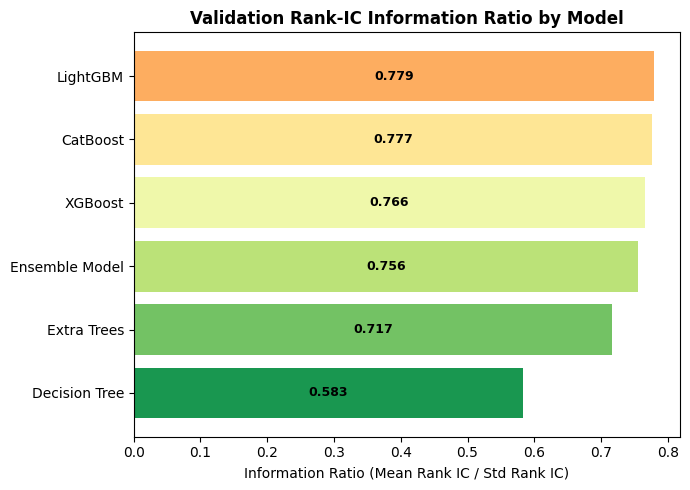

In [24]:
# --- Plot: ICIR by Model (Bar Chart) ---
fig1, ax1 = plt.subplots(figsize=(7,5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(final_leaderboard)))
bars = ax1.barh(final_leaderboard["model"], final_leaderboard["rank_ic_ir"], color=colors)
ax1.set_xlabel("Information Ratio (Mean Rank IC / Std Rank IC)")
ax1.set_title("Validation Rank-IC Information Ratio by Model", fontsize=12, fontweight="bold")
ax1.axvline(x=0, color="black", linestyle="--", alpha=0.3)

# Place the score in the center of the bar
for i, (idx, row) in enumerate(final_leaderboard.iterrows()):
    ax1.text(
        row["rank_ic_ir"] / 2,
        i, 
        f"{row['rank_ic_ir']:.3f}", 
        va="center", 
        ha="center",
        fontsize=9,
        color="black",
        fontweight="bold"
    )
ax1.invert_yaxis()
plt.tight_layout()
plt.show()

### Monthly Rank IC Time Series for the Leading Models

Finally, we plot the monthly Rank IC time series for the strongest model and the ensemble model on the validation set.

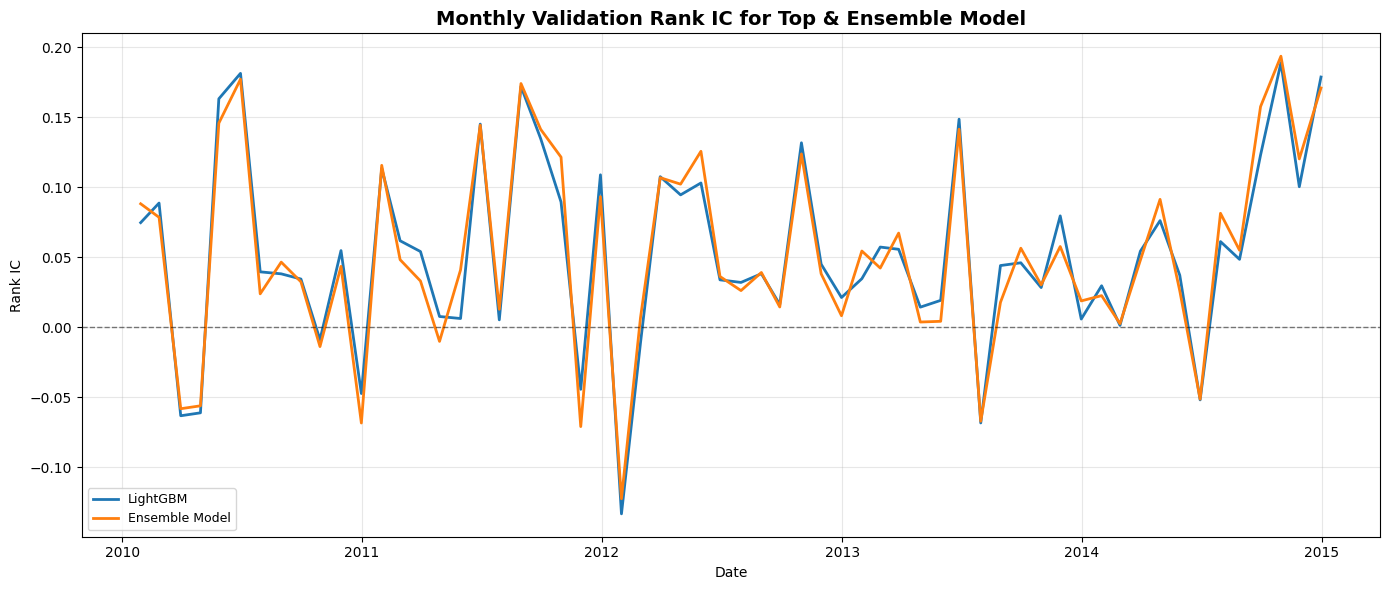

In [25]:
# Get top model
top_model = final_leaderboard.loc[0, "model"]

# Try to find the ensemble model in the leaderboard
ensemble_candidates = [m for m in final_leaderboard["model"] if "ensemble" in m.lower()]
if ensemble_candidates:
    ensemble_model = ensemble_candidates[0]
else:
    ensemble_model = None

models_to_plot = [top_model]
if ensemble_model and ensemble_model not in models_to_plot:
    models_to_plot.append(ensemble_model)

monthly_ic_plot_df = pd.concat(
    [best_monthly_ic[m].rename(m) for m in models_to_plot],
    axis=1,
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
for col in monthly_ic_plot_df.columns:
    ax.plot(monthly_ic_plot_df.index, monthly_ic_plot_df[col], label=col, linewidth=2)
ax.axhline(0.0, linestyle="--", linewidth=1, color="black", alpha=0.5)
ax.set_title("Monthly Validation Rank IC for Top & Ensemble Model", fontsize=14, fontweight="bold")
ax.set_ylabel("Rank IC")
ax.set_xlabel("Date")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  Model Refit on Pretest Set and Test Set Evaluation
In this section, we complete the model selection workflow by:
1. **Refitting the winning model** on the full pretest set (Train + Validation: 2000-2015)
2. **Evaluating on the untouched test set** (2015+) for final out-of-sample performance
3. **Creating quantile portfolios** to assess economic significance
4. **Computing portfolio statistics** (returns, Sharpe ratio, max drawdown)

### Why Refit on Pretest Set?
- The pretest set combines training and validation data, giving us more observations for final model estimation
- This is standard practice to maximize data usage before final out-of-sample testing
- The test set remains completely untouched until this final evaluation

### Refit Winning Model on Pretest Set

This cell handles **any winning model** scenario:
- **Individual Model**: Refit only the winner on pretest data
- **Ensemble Model**: Refit all component models on pretest data and average predictions

We use the best hyperparameters stored in `tuning_results` from the validation phase.

In [53]:
# Identify winning model from validation
best_model_name = final_leaderboard.loc[0, "model"]

# Helper function to instantiate model from name and params
def instantiate_model(model_name, params):
    """Create model instance based on name and hyperparameters."""
    # Clean params (remove any model-specific flags that shouldn't be passed during init)
    clean_params = {k: v for k, v in params.items()}
    
    if model_name == "Decision Tree":
        return DecisionTreeRegressor(**clean_params, random_state=RANDOM_STATE)
    elif model_name == "Extra Trees":
        return ExtraTreesRegressor(**clean_params, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == "LightGBM":
        return LGBMRegressor(**clean_params, objective="regression", 
                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    elif model_name == "XGBoost":
        return XGBRegressor(**clean_params, objective="reg:squarederror", 
                           random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    elif model_name == "CatBoost":
        return CatBoostRegressor(**clean_params, loss_function="RMSE", 
                                random_seed=RANDOM_STATE, verbose=False)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

# Store refitted models and test predictions
pretest_models = {}
test_predictions = {}

# Determine which models to refit
if best_model_name == "Ensemble Model":
    # Refit ALL individual models for ensemble
    models_to_refit = [k for k in tuning_results.keys() if k != "Ensemble Model"]
else:
    # Refit only the winning individual model
    models_to_refit = [best_model_name]

# Refit loop
for model_name in models_to_refit:    
    # Get best params from tuning results
    best_params = tuning_results[model_name]["best_params"]
    
    # Instantiate and fit on pretest data
    model = instantiate_model(model_name, best_params)
    model.fit(pretest_X, pretest_y)
    pretest_models[model_name] = model
    
    # Predict on test set
    test_pred = model.predict(test_X)
    test_predictions[model_name] = pd.Series(test_pred, index=test_X.index, name=model_name)
    
# Create final test predictions (average if ensemble, single if individual)
if best_model_name == "Ensemble Model":
    test_pred_df = pd.concat(test_predictions.values(), axis=1)
    ensemble_test_pred = test_pred_df.mean(axis=1)
    ensemble_test_pred.name = "Ensemble Model"
    final_test_predictions = ensemble_test_pred
else:
    final_test_predictions = test_predictions[best_model_name]

### Test Set Evaluation: Rank IC Metrics

We evaluate the model on the test set using the same Rank IC metrics as validation.

,Mean Rank IC,Std Rank IC,Rank IC IR,N Months
Test,0.055688,0.081129,0.686414,120


,Metric,Validation,Test
0,Mean Rank IC,0.0525,0.0557
1,Std Rank IC,0.0674,0.0811
2,Rank IC IR,0.7793,0.6864
3,N Months,60.0000,120.0000


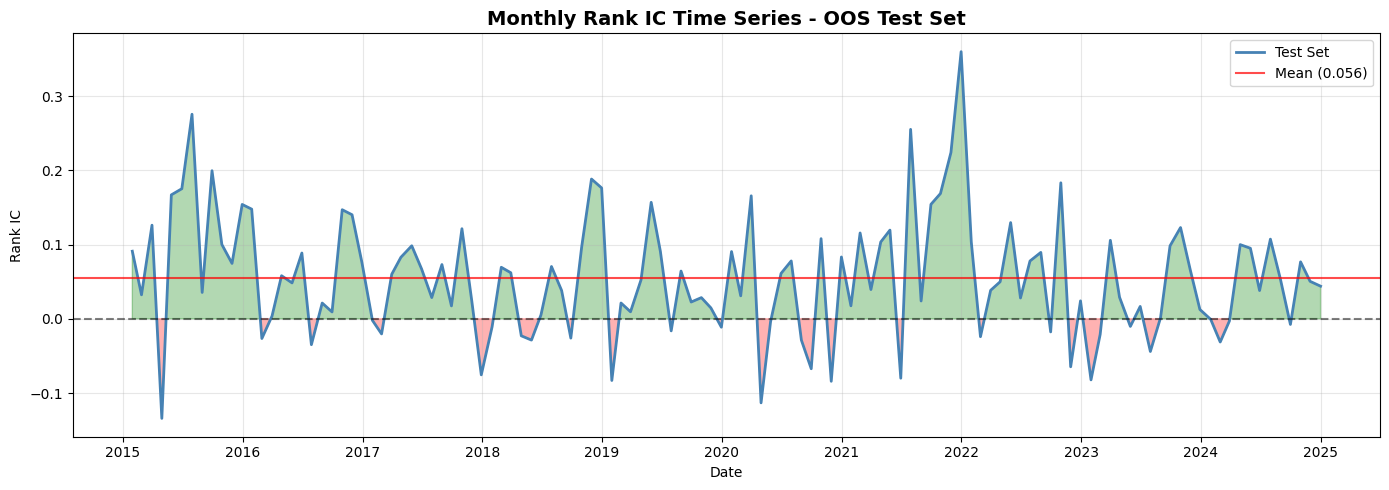

In [54]:
# Extract test set returns and dates
test_realized_ret = test_set_data["ret"].values
test_dates = test_set_data.index.copy()

# Evaluate on test set
test_monthly_ic = compute_monthly_rank_ic(
    predictions=final_test_predictions.values,
    realized_returns=test_realized_ret,
    dates=test_dates,
)

test_summary = summarize_rank_ic(test_monthly_ic)

# DataFrame with test set result
test_only_df = pd.DataFrame({
    "Mean Rank IC": [test_summary["mean_rank_ic"]],
    "Std Rank IC": [test_summary["std_rank_ic"]],
    "Rank IC IR": [test_summary["rank_ic_ir"]],
    "N Months": [test_summary["n_months"]]
}, index=["Test"])

display(
    test_only_df.style.set_caption("Test Set Performance")
    .format({
        "Test": "{:.4f}"
    })
)

# Get validation summary for best model
_, val_summary = evaluate_predictions(
    predictions=np.asarray(best_val_predictions[best_model_name]),
    realized_returns=np.asarray(val_realized_ret),
    dates=val_dates,
)

comparison_df = pd.DataFrame({
    "Metric": ["Mean Rank IC", "Std Rank IC", "Rank IC IR", "N Months"],
    "Validation": [
        val_summary["mean_rank_ic"],
        val_summary["std_rank_ic"],
        val_summary["rank_ic_ir"],
        val_summary["n_months"]
    ],
    "Test": [
        test_summary["mean_rank_ic"],
        test_summary["std_rank_ic"],
        test_summary["rank_ic_ir"],
        test_summary["n_months"]
    ]
})

display(
    comparison_df.style.set_caption("Validation vs Test Set Performance")
    .format({
        "Validation": "{:.4f}",
        "Test": "{:.4f}"
    })
)

fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))

# Plot: Monthly Rank IC Time Series
ax1.plot(test_monthly_ic.index, test_monthly_ic.values, linewidth=2, color='steelblue', label='Test Set')
ax1.axhline(y=0, linestyle='--', color='black', alpha=0.5)
ax1.axhline(y=test_summary['mean_rank_ic'], linestyle='-', color='red', alpha=0.7, 
            label=f"Mean ({test_summary['mean_rank_ic']:.3f})")
ax1.fill_between(test_monthly_ic.index, 0, test_monthly_ic.values, 
                 where=(test_monthly_ic.values >= 0), interpolate=True, color='green', alpha=0.3)
ax1.fill_between(test_monthly_ic.index, 0, test_monthly_ic.values, 
                 where=(test_monthly_ic.values < 0), interpolate=True, color='red', alpha=0.3)
ax1.set_title("Monthly Rank IC Time Series - OOS Test Set", fontsize=14, fontweight='bold')
ax1.set_ylabel("Rank IC")
ax1.set_xlabel("Date")
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Quantile Portfolio Analysis

We now create quintile portfolios based on the model's predictions to assess economic significance. Stocks are sorted into 5 equal groups (quintiles) each month based on predicted returns.

In [55]:
# Note: test_set_data has 'permno' and 'ret', test_X index aligns with test_set_data index
test_eval_df = pd.DataFrame({
    'date': test_dates,
    'permno': test_set_data['permno'].values,
    'pred': final_test_predictions.values,
    'ret': test_realized_ret
})

# Create quintile bins based on predictions (within each month)
# Use pd.qcut with duplicates='drop' to handle cases with few stocks
test_eval_df['quintile'] = test_eval_df.groupby('date')['pred'].transform(
    lambda x: pd.qcut(x, q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
)

# Handle edge case where qcut might fail due to ties (fallback to rank-based)
if test_eval_df['quintile'].isna().any():
    test_eval_df['pred_rank'] = test_eval_df.groupby('date')['pred'].transform(
        lambda x: x.rank(pct=True)
    )
    test_eval_df['quintile'] = pd.cut(test_eval_df['pred_rank'],
                                      bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                      labels=[1, 2, 3, 4, 5])

# Calculate equal-weighted average return for each quintile each month
quintile_returns = test_eval_df.groupby(['date', 'quintile'])['ret'].mean().unstack()

# Ensure all quintiles exist (1-5)
for q in [1, 2, 3, 4, 5]:
    if q not in quintile_returns.columns:
        quintile_returns[q] = np.nan

quintile_returns = quintile_returns[[1, 2, 3, 4, 5]]  # Reorder columns

display(
    quintile_returns.head(12).style.set_caption("Monthly Returns by Quintile (First 12 Months)")
    .format("{:.4f}")
)

# Prepare a summary DataFrame of mean returns and long-short
summary_df = pd.DataFrame({
    'Mean': [
        quintile_returns[1].mean(),
        quintile_returns[2].mean(),
        quintile_returns[3].mean(),
        quintile_returns[4].mean(),
        quintile_returns[5].mean(),
        quintile_returns[5].mean() - quintile_returns[1].mean()
    ]
}, index=[
    'Q1 (Lowest Pred)',
    'Q2',
    'Q3',
    'Q4',
    'Q5 (Highest Pred)',
    'Q5 - Q1 (Long-Short)'
])

display(
    summary_df.style.set_caption("Quintile Return Statistics (Means)").format("{:.4f}")
)

quintile,1,2,3,4,5
date,,,,,
2015-01-30 00:00:00,-0.0378,-0.0414,-0.0386,-0.0262,-0.0260
2015-02-27 00:00:00,0.0671,0.0636,0.0566,0.0602,0.0849
2015-03-31 00:00:00,-0.0366,0.0029,0.0085,0.0108,-0.0023
2015-04-30 00:00:00,0.0681,0.0125,-0.0138,-0.0148,0.0024
2015-05-29 00:00:00,-0.0249,-0.0011,0.0151,0.0171,0.0145
2015-06-30 00:00:00,-0.0388,-0.0091,0.0017,0.0075,0.0059
2015-07-31 00:00:00,-0.0989,-0.0436,-0.0203,-0.0069,-0.0050
2015-08-31 00:00:00,-0.0388,-0.0500,-0.0486,-0.0451,-0.0255
2015-09-30 00:00:00,-0.0962,-0.0677,-0.0349,-0.0343,-0.0362


,Mean
Q1 (Lowest Pred),-0.0020
Q2,0.0078
Q3,0.0094
Q4,0.0111
Q5 (Highest Pred),0.0182
Q5 - Q1 (Long-Short),0.0202


### Cumulative Returns of Quantile Portfolios

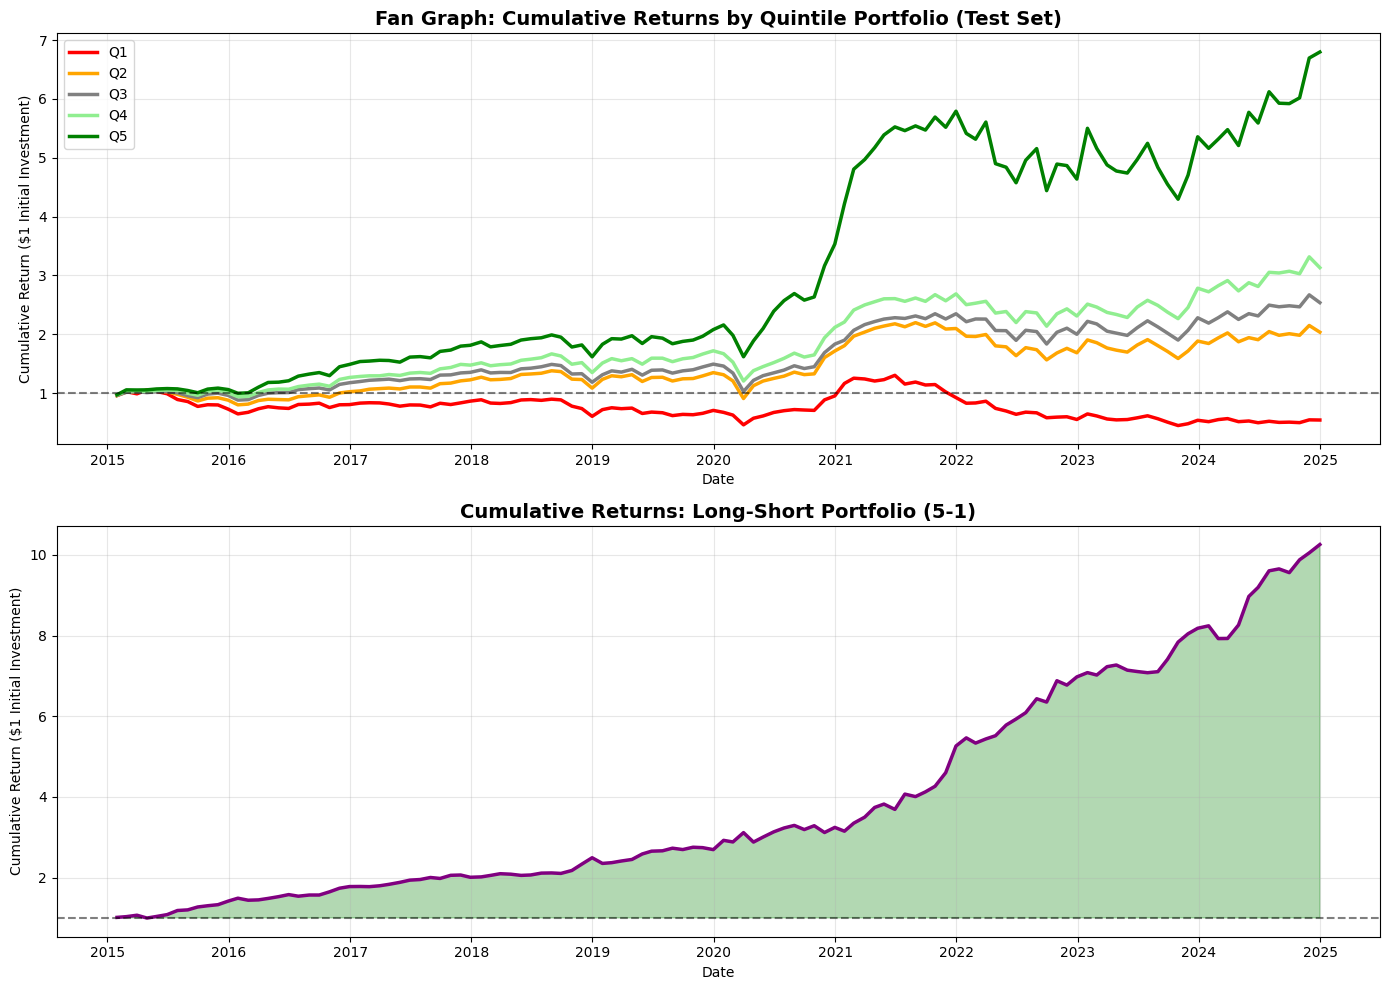

In [62]:
# Calculate cumulative returns for each quintile
cumulative_returns = (1 + quintile_returns).cumprod()

# Calculate long-short (top minus bottom) returns from quintile_returns
def _extract_quantile_number(column_label):
    match = re.search(r"\d+", str(column_label))
    return int(match.group()) if match else None

quantile_numbers = {
    column: _extract_quantile_number(column) for column in quintile_returns.columns
}
ranked_columns = [
    column for column, number in quantile_numbers.items() if number is not None
]

if ranked_columns:
    bottom_quintile_col = min(ranked_columns, key=lambda c: quantile_numbers[c])
    top_quintile_col = max(ranked_columns, key=lambda c: quantile_numbers[c])
else:
    bottom_quintile_col = quintile_returns.columns[0]
    top_quintile_col = quintile_returns.columns[-1]

long_short_returns = (
    quintile_returns[top_quintile_col] - quintile_returns[bottom_quintile_col]
)
cumulative_ls = (1 + long_short_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Fan Graph - All Quintiles
ax1 = axes[0]
colors = ['red', 'orange', 'gray', 'lightgreen', 'green']
for i, col in enumerate(cumulative_returns.columns):
    ax1.plot(
        cumulative_returns.index,
        cumulative_returns[col],
        linewidth=2.5,
        label=f'Q{col}',
        color=colors[i % len(colors)],
    )

ax1.set_title("Fan Graph: Cumulative Returns by Quintile Portfolio (Test Set)", 
              fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative Return ($1 Initial Investment)")
ax1.set_xlabel("Date")
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='black', linestyle='--', alpha=0.5)

# Plot 2: Long-Short Portfolio Cumulative Returns
ax2 = axes[1]
ax2.plot(cumulative_ls.index, cumulative_ls.values, linewidth=2.5, color='purple')
ax2.fill_between(cumulative_ls.index, 1, cumulative_ls.values, 
                 where=(cumulative_ls.values >= 1), interpolate=True, color='green', alpha=0.3)
ax2.fill_between(cumulative_ls.index, 1, cumulative_ls.values, 
                 where=(cumulative_ls.values < 1), interpolate=True, color='red', alpha=0.3)
ax2.set_title(
    f"Cumulative Returns: Long-Short Portfolio ({top_quintile_col}-{bottom_quintile_col})",
    fontsize=14,
    fontweight='bold',
)
ax2.set_ylabel("Cumulative Return ($1 Initial Investment)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Portfolio Statistics

,Mean Monthly Return (%),Std Monthly Return (%),Annualized Return (%),Annualized Std (%),Sharpe Ratio,Maximum Drawdown (%),Win Rate (%),N Months
Q1,-0.20,7.92,-2.35,27.43,-0.09,-65.47,49.17,120.00
Q2,0.78,6.18,9.41,21.39,0.44,-34.16,58.33,120.00
Q3,0.94,5.66,11.28,19.60,0.58,-31.14,61.67,120.00
Q4,1.11,5.50,13.28,19.04,0.70,-29.87,61.67,120.00
Q5,1.82,6.60,21.86,22.88,0.96,-25.83,62.50,120.00
Long-Short (Q5-Q1),2.02,3.48,24.21,12.05,2.01,-7.54,75.00,120.00


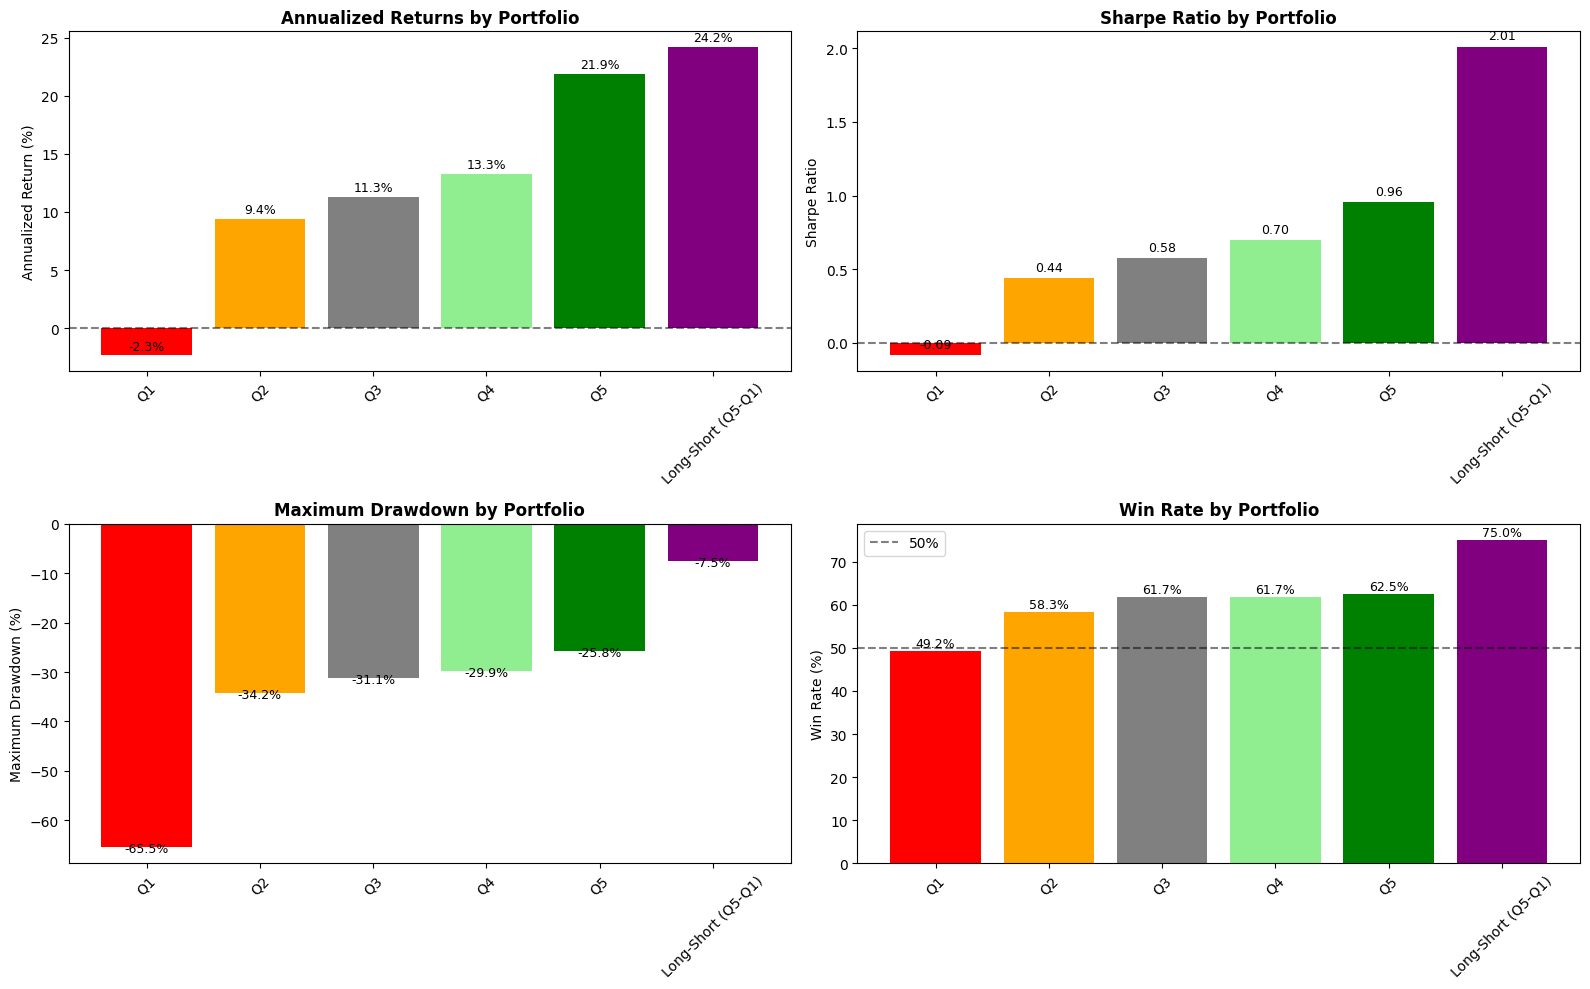

In [69]:
def calculate_portfolio_stats(returns_series, annualization_factor=12):
    """
    Calculate comprehensive portfolio statistics.
    
    Parameters
    ----------
    returns_series : pd.Series
        Monthly returns series
    annualization_factor : int
        Number of periods per year (12 for monthly)
    
    Returns
    -------
    dict
        Dictionary of portfolio statistics
    """
    returns = returns_series.dropna()
    
    if len(returns) == 0:
        return {
            "Mean Monthly Return (%)": np.nan,
            "Std Monthly Return (%)": np.nan,
            "Annualized Return (%)": np.nan,
            "Annualized Std (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Maximum Drawdown (%)": np.nan,
            "Win Rate (%)": np.nan,
            "N Months": 0
        }
    
    # Basic statistics
    mean_monthly = returns.mean()
    std_monthly = returns.std(ddof=1)
    
    # Annualized statistics
    mean_annual = mean_monthly * annualization_factor
    std_annual = std_monthly * np.sqrt(annualization_factor)
    
    # Sharpe Ratio (assuming 0% risk-free rate for simplicity)
    sharpe_ratio = mean_annual / std_annual if std_annual > 0 else np.nan
    
    # Maximum Drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.expanding().max()
    drawdowns = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdowns.min()
    
    # Win rate
    win_rate = (returns > 0).sum() / len(returns)
    
    return {
        "Mean Monthly Return (%)": mean_monthly * 100,
        "Std Monthly Return (%)": std_monthly * 100,
        "Annualized Return (%)": mean_annual * 100,
        "Annualized Std (%)": std_annual * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate * 100,
        "N Months": len(returns)
    }
    
# Calculate statistics for all quintiles and long-short portfolio
portfolio_stats = {}

for quintile in [1, 2, 3, 4, 5]:
    portfolio_stats[f"Q{quintile}"] = calculate_portfolio_stats(quintile_returns[quintile])

portfolio_stats["Long-Short (Q5-Q1)"] = calculate_portfolio_stats(long_short_returns)

# Create display DataFrame
stats_df = pd.DataFrame(portfolio_stats).T

display(
    stats_df.style.set_caption("Portfolio Statistics - Test Set")
    .format("{:.2f}")
)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Annualized Returns by Portfolio
ax1 = axes[0, 0]
annual_returns = stats_df["Annualized Return (%)"]
colors = ['red', 'orange', 'gray', 'lightgreen', 'green', 'purple']
bars = ax1.bar(stats_df.index, annual_returns.values, color=colors)
ax1.set_title("Annualized Returns by Portfolio", fontsize=12, fontweight='bold')
ax1.set_ylabel("Annualized Return (%)")
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
for i, v in enumerate(annual_returns.values):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

# Plot 2: Sharpe Ratio by Portfolio
ax2 = axes[0, 1]
sharpe_ratios = stats_df["Sharpe Ratio"]
bars = ax2.bar(stats_df.index, sharpe_ratios.values, color=colors)
ax2.set_title("Sharpe Ratio by Portfolio", fontsize=12, fontweight='bold')
ax2.set_ylabel("Sharpe Ratio")
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
for i, v in enumerate(sharpe_ratios.values):
    ax2.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

# Plot 3: Maximum Drawdown by Portfolio
ax3 = axes[1, 0]
max_dd = stats_df["Maximum Drawdown (%)"]
bars = ax3.bar(stats_df.index, max_dd.values, color=colors)
ax3.set_title("Maximum Drawdown by Portfolio", fontsize=12, fontweight='bold')
ax3.set_ylabel("Maximum Drawdown (%)")
ax3.tick_params(axis='x', rotation=45)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
for i, v in enumerate(max_dd.values):
    ax3.text(i, v - 1, f"{v:.1f}%", ha='center', fontsize=9)

# Plot 4: Win Rate by Portfolio
ax4 = axes[1, 1]
win_rates = stats_df["Win Rate (%)"]
bars = ax4.bar(stats_df.index, win_rates.values, color=colors)
ax4.set_title("Win Rate by Portfolio", fontsize=12, fontweight='bold')
ax4.set_ylabel("Win Rate (%)")
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50%')
for i, v in enumerate(win_rates.values):
    ax4.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
ax4.legend()

plt.tight_layout()
plt.show()

### Monthly Long - Short Returns Time Series

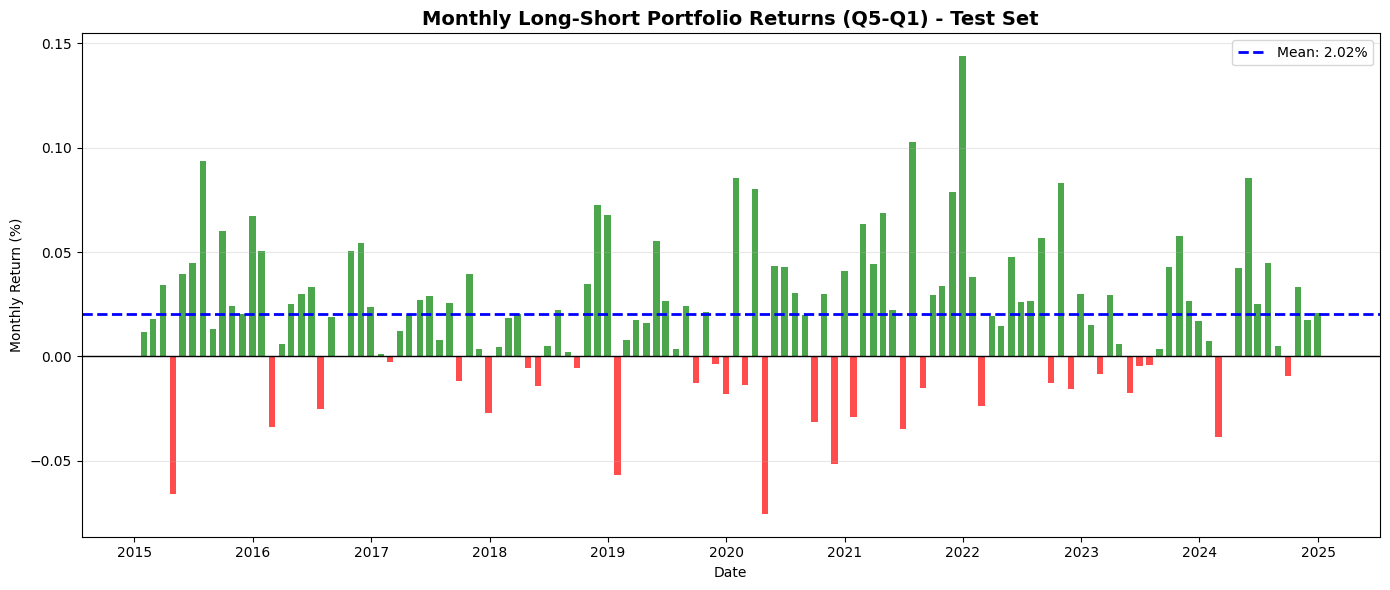

In [70]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot monthly long-short returns
ax.bar(long_short_returns.index, long_short_returns.values, 
       color=np.where(long_short_returns >= 0, 'green', 'red'), 
       alpha=0.7, width=20)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=long_short_returns.mean(), color='blue', linestyle='--', 
           linewidth=2, label=f"Mean: {long_short_returns.mean()*100:.2f}%")
ax.set_title("Monthly Long-Short Portfolio Returns (Q5-Q1) - Test Set", 
             fontsize=14, fontweight='bold')
ax.set_ylabel("Monthly Return (%)")
ax.set_xlabel("Date")
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [72]:
# Create final summary
final_summary = {
    "Model": best_model_name,
    "Components": ", ".join([k for k in tuning_results.keys() if k != "Ensemble Model"]) if best_model_name == "Ensemble Model" else best_model_name,
    "Test Period": f"{test_dates.min().strftime('%Y-%m')} to {test_dates.max().strftime('%Y-%m')}",
    "Test Months": test_summary['n_months'],
    "Mean Rank IC": f"{test_summary['mean_rank_ic']:.4f}",
    "Std Rank IC": f"{test_summary['std_rank_ic']:.4f}",
    "Rank IC IR": f"{test_summary['rank_ic_ir']:.4f}",
    "Long-Short Ann. Return": f"{stats_df.loc['Long-Short (Q5-Q1)', 'Annualized Return (%)']:.2f}%",
    "Long-Short Ann. Std": f"{stats_df.loc['Long-Short (Q5-Q1)', 'Annualized Std (%)']:.2f}%",
    "Long-Short Sharpe": f"{stats_df.loc['Long-Short (Q5-Q1)', 'Sharpe Ratio']:.2f}",
    "Long-Short Max DD": f"{stats_df.loc['Long-Short (Q5-Q1)', 'Maximum Drawdown (%)']:.2f}%",
}

summary_df = pd.DataFrame(list(final_summary.items()), columns=["Metric", "Value"])

display(
    summary_df.style.set_caption("Final Project Summary - Test Set Evaluation")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

# Prepare key findings as a DataFrame for display
findings = [
    [f"✓ Model achieves Rank IC IR of {test_summary['rank_ic_ir']:.4f} on test set"],
    [f"✓ Long-Short portfolio generates {stats_df.loc['Long-Short (Q5-Q1)', 'Annualized Return (%)']:.2f}% annualized return"],
    [f"✓ Sharpe Ratio of {stats_df.loc['Long-Short (Q5-Q1)', 'Sharpe Ratio']:.2f} indicates risk-adjusted performance"],
    [f"✓ Maximum drawdown of {stats_df.loc['Long-Short (Q5-Q1)', 'Maximum Drawdown (%)']:.2f}% shows risk control"],
    [f"✓ Fan graph shows divergence between Q5 (top) and Q1 (bottom) quintiles"]
]
findings_df = pd.DataFrame(findings, columns=["Key Findings"])
display(
    findings_df.style.set_caption("Key Findings - Test Set Performance")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

Metric,Value
Model,LightGBM
Components,LightGBM
Test Period,2015-01 to 2024-12
Test Months,120
Mean Rank IC,0.0557
Std Rank IC,0.0811
Rank IC IR,0.6864
Long-Short Ann. Return,24.21%
Long-Short Ann. Std,12.05%
Long-Short Sharpe,2.01


Key Findings
✓ Model achieves Rank IC IR of 0.6864 on test set
✓ Long-Short portfolio generates 24.21% annualized return
✓ Sharpe Ratio of 2.01 indicates risk-adjusted performance
✓ Maximum drawdown of -7.54% shows risk control
✓ Fan graph shows divergence between Q5 (top) and Q1 (bottom) quintiles
